In [3]:
import pandas as pd

# Load datasets with encoding
ecom_df = pd.read_csv(r"C:\rakshitha\FDS\customer-dna\1\data.csv", encoding="ISO-8859-1")
behavior_df = pd.read_csv(r"C:\rakshitha\FDS\customer-dna\2\Mall_Customers.csv", encoding="ISO-8859-1")
retail_df = pd.read_excel(r"C:\rakshitha\FDS\customer-dna\3\Online Retail.xlsx")  # Excel files don't need encoding

# Display basic info
print("E-Commerce Dataset:")
print(ecom_df.info(), "\n")

print("Customer Behavior Dataset:")
print(behavior_df.info(), "\n")

print("Online Retail Dataset:")
print(retail_df.info(), "\n")


E-Commerce Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None 

Customer Behavior Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     20

In [5]:
# Convert InvoiceDate to datetime format (E-Commerce)
ecom_df["InvoiceDate"] = pd.to_datetime(ecom_df["InvoiceDate"])

# Convert CustomerID to integer (drop NaN values first)
ecom_df = ecom_df.dropna(subset=["CustomerID"])
ecom_df["CustomerID"] = ecom_df["CustomerID"].astype(int)

retail_df = retail_df.dropna(subset=["CustomerID"])
retail_df["CustomerID"] = retail_df["CustomerID"].astype(int)

# Fill missing descriptions with "Unknown"
ecom_df["Description"] = ecom_df["Description"].fillna("Unknown")
retail_df["Description"] = retail_df["Description"].fillna("Unknown")

# Remove duplicate rows
ecom_df = ecom_df.drop_duplicates()
retail_df = retail_df.drop_duplicates()

# Verify changes
print("E-Commerce Dataset after Cleaning:")
print(ecom_df.info(), "\n")

print("Online Retail Dataset after Cleaning:")
print(retail_df.info(), "\n")


E-Commerce Dataset after Cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  int32         
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(4)
memory usage: 26.0+ MB
None 

Online Retail Dataset after Cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    

In [7]:
import datetime as dt

# Define snapshot date (latest purchase date + 1)
snapshot_date = ecom_df["InvoiceDate"].max() + dt.timedelta(days=1)

# Calculate RFM metrics
rfm_df = ecom_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "count",  # Frequency
    "UnitPrice": lambda x: (x * ecom_df.loc[x.index, "Quantity"]).sum()  # Monetary
})

# Rename columns
rfm_df.columns = ["Recency", "Frequency", "Monetary"]

# Display summary
print(rfm_df.describe())

# Save for later use
rfm_df.to_csv("rfm_analysis.csv")


           Recency    Frequency       Monetary
count  4372.000000  4372.000000    4372.000000
mean     92.047118    91.858188    1893.531433
std     100.765435   229.223566    8218.696204
min       1.000000     1.000000   -4287.630000
25%      17.000000    17.000000     291.795000
50%      50.000000    41.000000     644.070000
75%     143.000000    99.250000    1608.335000
max     374.000000  7812.000000  279489.020000


In [9]:
# Remove customers with negative monetary values
rfm_df = rfm_df[rfm_df["Monetary"] > 0]

# Display updated summary
print(rfm_df.describe())


           Recency    Frequency      Monetary
count  4320.000000  4320.000000  4.320000e+03
mean     90.359722    92.844676  1.919386e+03
std      99.137988   230.401172  8.264299e+03
min       1.000000     1.000000  7.105427e-15
25%      17.000000    18.000000  3.008450e+02
50%      49.500000    42.000000  6.533650e+02
75%     138.000000   101.000000  1.624158e+03
max     374.000000  7812.000000  2.794890e+05


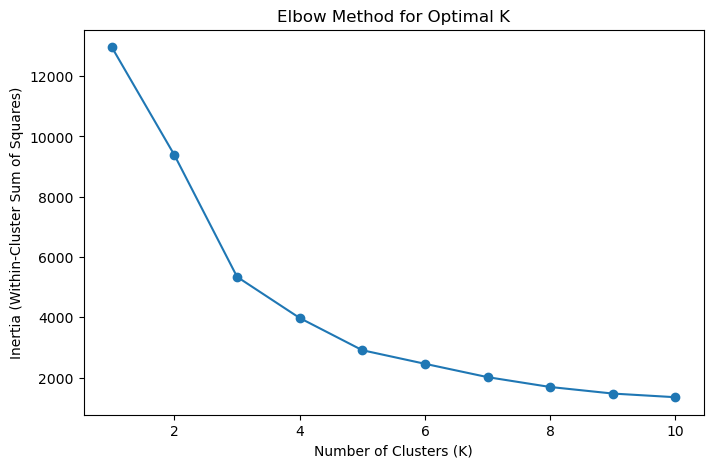

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Step 1: Scale the data (K-Means needs normalized data)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df)

# Step 2: Use the Elbow Method to find optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K")
plt.show()


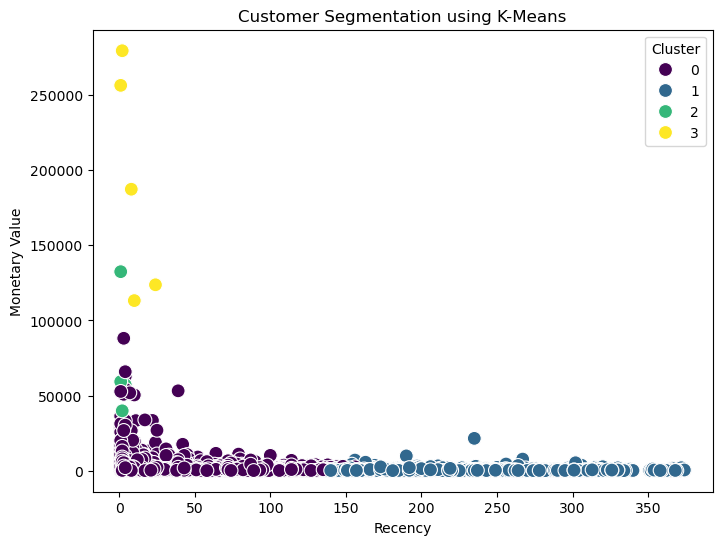

In [13]:
# Apply K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42)
rfm_df["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Visualize the clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=rfm_df["Recency"], y=rfm_df["Monetary"], hue=rfm_df["Cluster"], palette="viridis", s=100)
plt.xlabel("Recency")
plt.ylabel("Monetary Value")
plt.title("Customer Segmentation using K-Means")
plt.legend(title="Cluster")
plt.show()


In [15]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Assuming 'rfm_scaled' is your RFM data after standardization
silhouette_avg = silhouette_score(rfm_scaled, kmeans.labels_)
db_index = davies_bouldin_score(rfm_scaled, kmeans.labels_)

print(f"Silhouette Score: {silhouette_avg:.3f}")
print(f"Davies-Bouldin Index: {db_index:.3f}")


Silhouette Score: 0.601
Davies-Bouldin Index: 0.641


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

for k in [3, 5]:  
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(rfm_df)  # Assuming rfm_df is your RFM data

    # Compute evaluation metrics
    silhouette = silhouette_score(rfm_df, clusters)
    db_index = davies_bouldin_score(rfm_df, clusters)

    print(f"K={k}: Silhouette Score = {silhouette:.3f}, Davies-Bouldin Index = {db_index:.3f}")


K=3: Silhouette Score = 0.963, Davies-Bouldin Index = 0.362
K=5: Silhouette Score = 0.815, Davies-Bouldin Index = 0.436


In [19]:
import pandas as pd

rfm_df["Cluster"] = kmeans.labels_  # Assign K=3 clusters
print(rfm_df.groupby("Cluster").agg({"Recency": "mean", "Frequency": "mean", "Monetary": "mean"}))
print(rfm_df["Cluster"].value_counts())


           Recency    Frequency       Monetary
Cluster                                       
0        95.667662    66.898259     958.737100
1         9.200000  1903.400000  128969.264000
2         1.500000  1259.000000  267963.755000
3         6.814815  1119.333333   40961.305926
4        20.815789   337.973684    8086.076429
Cluster
0    4020
4     266
3      27
1       5
2       2
Name: count, dtype: int64


In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting Features for Clustering
X = rfm_df[['Recency', 'Frequency', 'Monetary']]

# Re-run KMeans with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans.fit_predict(X)

# Cluster Summary
cluster_summary = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print(cluster_summary)

# Count of customers per cluster
print(rfm_df['Cluster'].value_counts())


         Recency  Frequency   Monetary
Cluster                               
0          92.53      77.61    1173.44
1           7.87    1508.47   71538.93
2           3.67     956.00  241083.23
3          15.48     486.65   15362.60
Cluster
0    4200
3     102
1      15
2       3
Name: count, dtype: int64


In [23]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)  # Tune these parameters
rfm_df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Check number of clusters formed
print(rfm_df['DBSCAN_Cluster'].value_counts())


DBSCAN_Cluster
 0    4295
-1      19
 1       6
Name: count, dtype: int64


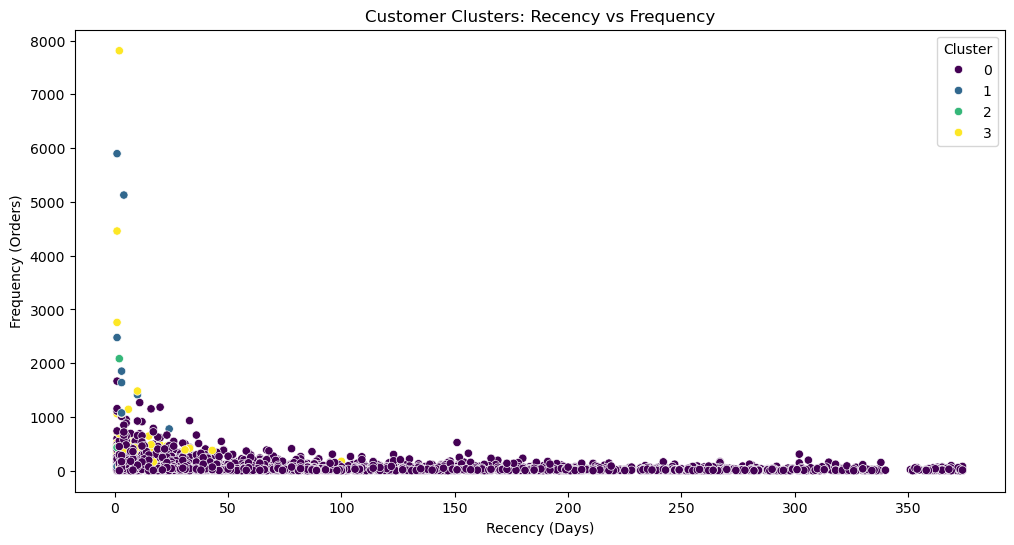

In [25]:
plt.figure(figsize=(12, 6))

# Scatter Plot (Recency vs Frequency)
sns.scatterplot(x=rfm_df['Recency'], y=rfm_df['Frequency'], hue=rfm_df['Cluster'], palette='viridis')

plt.title('Customer Clusters: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency (Orders)')
plt.show()


In [48]:
import pandas as pd

# Load data
df = pd.read_csv(r"C:\rakshitha\FDS\customer-dna\1\data.csv", encoding="ISO-8859-1")

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Remove missing CustomerIDs
df = df.dropna(subset=["CustomerID"])

# Remove invalid transactions (negative Quantity or UnitPrice)
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Remove refunds (InvoiceNo starts with "C")
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Compute TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Save cleaned data
df.to_csv(r"C:\rakshitha\FDS\customer-dna\1\cleaned_data.csv", index=False)


print(df.head())  # Verify the cleaned dataset


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  


In [50]:
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv(r"C:\rakshitha\FDS\customer-dna\1\cleaned_data.csv", encoding="ISO-8859-1")  # Replace with actual path

# Ensure InvoiceDate is in datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Compute TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Compute RFM values
df_rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (df["InvoiceDate"].max() - x.max()).days,  # Recency
    "InvoiceNo": "count",  # Frequency
    "TotalPrice": "sum"  # Monetary
}).rename(columns={"InvoiceDate": "Recency", "InvoiceNo": "Frequency", "TotalPrice": "Monetary"})

# Reset index
df_rfm.reset_index(inplace=True)

print(df_rfm.head())  # Check the dataframe


   CustomerID  Recency  Frequency  Monetary
0     12346.0      325          1  77183.60
1     12347.0        1        182   4310.00
2     12348.0       74         31   1797.24
3     12349.0       18         73   1757.55
4     12350.0      309         17    334.40


In [54]:
print(df_rfm.columns)


Index(['CustomerID', 'Recency', 'Frequency', 'Monetary'], dtype='object')


In [56]:
from sklearn.cluster import KMeans

# Select features for clustering
rfm_features = df_rfm[['Recency', 'Frequency', 'Monetary']]

# Run K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df_rfm['Cluster_K3'] = kmeans.fit_predict(rfm_features)

# Check if clusters are assigned
print(df_rfm.head())


   CustomerID  Recency  Frequency  Monetary  Cluster_K3
0     12346.0      325          1  77183.60           2
1     12347.0        1        182   4310.00           0
2     12348.0       74         31   1797.24           0
3     12349.0       18         73   1757.55           0
4     12350.0      309         17    334.40           0


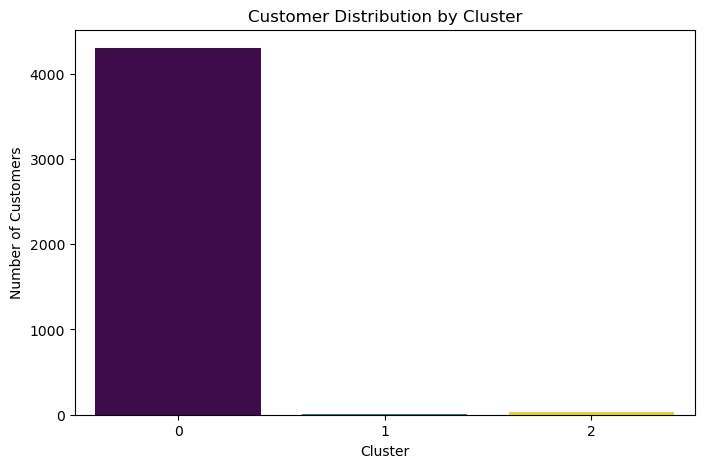

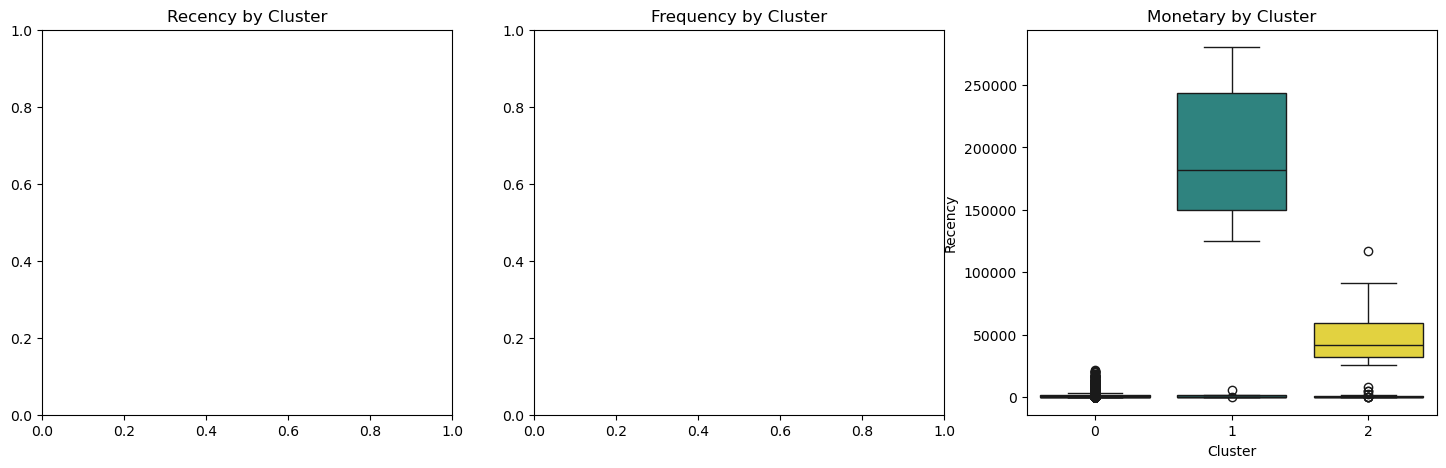

Column 'InvoiceDate' not found. Skipping spending trends plot.


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_rfm exists
if 'df_rfm' not in locals():
    raise ValueError("df_rfm is not defined. Make sure clustering has been done first.")

# Check if 'Cluster_K3' column exists
if 'Cluster_K3' in df_rfm.columns:
    df_rfm['Cluster'] = df_rfm['Cluster_K3']  # Assign correct cluster column
else:
    raise KeyError("Column 'Cluster_K3' not found. Verify clustering step.")

# 1. Cluster Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Cluster', data=df_rfm, hue='Cluster', palette='viridis', legend=False)  # FIXED
plt.title('Customer Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

# 2. Boxplots for RFM Variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(x='Cluster', y=col, data=df_rfm, hue='Cluster', palette='viridis', dodge=False, legend=False)  # FIXED
    axes[i].set_title(f'{col} by Cluster')
plt.show()

# 3. Spending Trends (if timestamps available)
if 'InvoiceDate' in df_rfm.columns:
    df_rfm['InvoiceDate'] = pd.to_datetime(df_rfm['InvoiceDate'], errors='coerce')
    
    # Drop NaT values after conversion
    df_rfm = df_rfm.dropna(subset=['InvoiceDate'])

    spending_trends = df_rfm.groupby([df_rfm['InvoiceDate'].dt.to_period('M'), 'Cluster'])['Monetary'].sum().unstack()
    
    spending_trends.plot(kind='line', figsize=(12, 6), marker='o')
    plt.title('Spending Trends by Cluster Over Time')
    plt.xlabel('Month')
    plt.ylabel('Total Monetary Value')
    plt.legend(title='Cluster')
    plt.show()
else:
    print("Column 'InvoiceDate' not found. Skipping spending trends plot.")


In [64]:
print(df_rfm.info())  # Check column types
print(df_rfm.describe())  # Inspect summary statistics
print(df_rfm.head())  # View first few rows


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   float64
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
 4   Cluster_K3  4338 non-null   int32  
 5   Cluster     4338 non-null   int32  
dtypes: float64(2), int32(2), int64(2)
memory usage: 169.6 KB
None
         CustomerID      Recency    Frequency       Monetary   Cluster_K3  \
count   4338.000000  4338.000000  4338.000000    4338.000000  4338.000000   
mean   15300.408022    91.536422    91.720609    2054.266460     0.016136   
std     1721.808492   100.014169   228.785094    8989.230441     0.175033   
min    12346.000000     0.000000     1.000000       3.750000     0.000000   
25%    13813.250000    17.000000    17.000000     307.415000     0.000000   
50%    15299.500000    50.000000    4

In [66]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scaling RFM values
scaler = StandardScaler()
df_rfm[['Recency', 'Frequency', 'Monetary']] = scaler.fit_transform(df_rfm[['Recency', 'Frequency', 'Monetary']])

# Trying different K values
for k in range(3, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df_rfm[f'Cluster_K{k}'] = kmeans.fit_predict(df_rfm[['Recency', 'Frequency', 'Monetary']])
    print(f"K={k} -> Cluster Distribution:\n", df_rfm[f'Cluster_K{k}'].value_counts())


K=3 -> Cluster Distribution:
 Cluster_K3
0    3245
1    1080
2      13
Name: count, dtype: int64
K=4 -> Cluster Distribution:
 Cluster_K4
0    3248
2    1080
3       6
1       4
Name: count, dtype: int64
K=5 -> Cluster Distribution:
 Cluster_K5
0    3017
1    1055
2     256
3       6
4       4
Name: count, dtype: int64


In [68]:
df_rfm['Cluster_K5'] = df_rfm['Cluster_K5'].replace({3: 2, 4: 2})  # Merge them into Cluster 2
print(df_rfm['Cluster_K5'].value_counts())  # Recheck distribution


Cluster_K5
0    3017
1    1055
2     266
Name: count, dtype: int64


In [70]:
df_rfm['Cluster'] = df_rfm['Cluster_K5'].map({
    0: 'Low-Value Customers',
    1: 'Regular Customers',
    2: 'High-Value Customers'
})


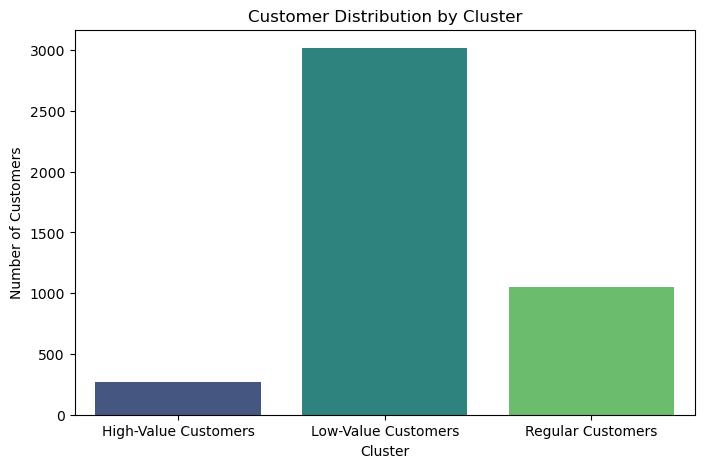

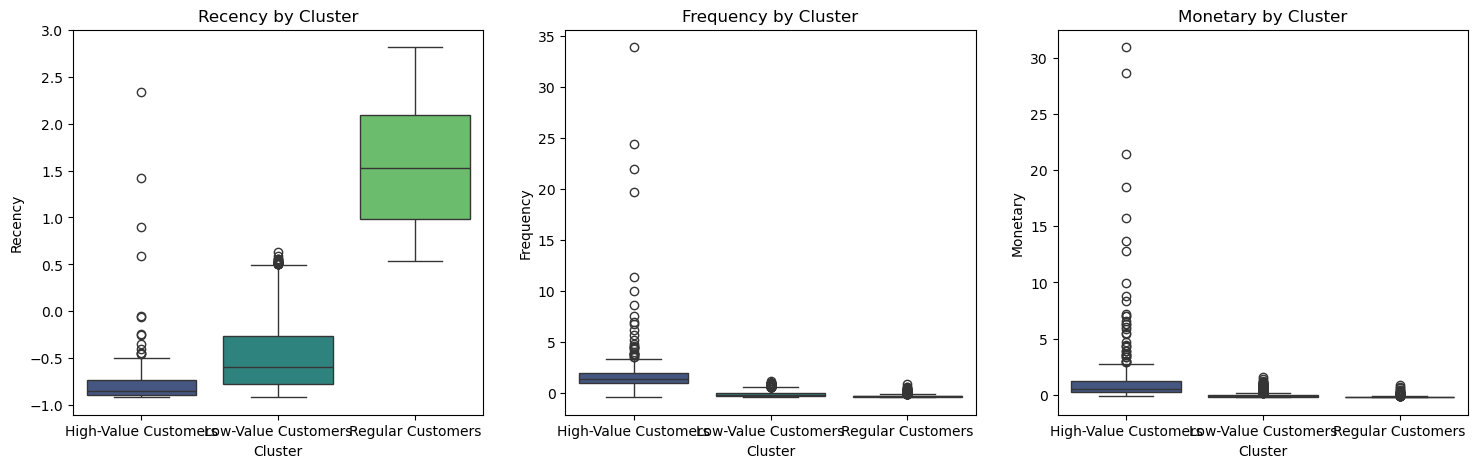

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix countplot warning
plt.figure(figsize=(8, 5))
sns.countplot(x='Cluster', data=df_rfm, hue='Cluster', palette='viridis', legend=False)
plt.title('Customer Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(x='Cluster', y=col, data=df_rfm, ax=axes[i], hue='Cluster', palette='viridis', legend=False)
    axes[i].set_title(f'{col} by Cluster')
plt.show()



In [78]:
from sklearn.metrics import silhouette_score
silhouette_score(df_rfm[['Recency', 'Frequency', 'Monetary']], df_rfm['Cluster'])


0.6084761524475473

In [80]:
cluster_summary = df_rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).reset_index()
print(cluster_summary)


                Cluster   Recency  Frequency  Monetary
0  High-Value Customers -0.767374   2.064383  1.603906
1   Low-Value Customers -0.481125  -0.084287 -0.080571
2     Regular Customers  1.569362  -0.279461 -0.173986


In [84]:
print(df.columns)


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Month'],
      dtype='object')


In [86]:
# Assuming df_rfm contains CustomerID and Cluster labels
df = df.merge(df_rfm[['CustomerID', 'Cluster']], on='CustomerID', how='left')


In [90]:
print(df.columns)


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Month', 'Cluster'],
      dtype='object')


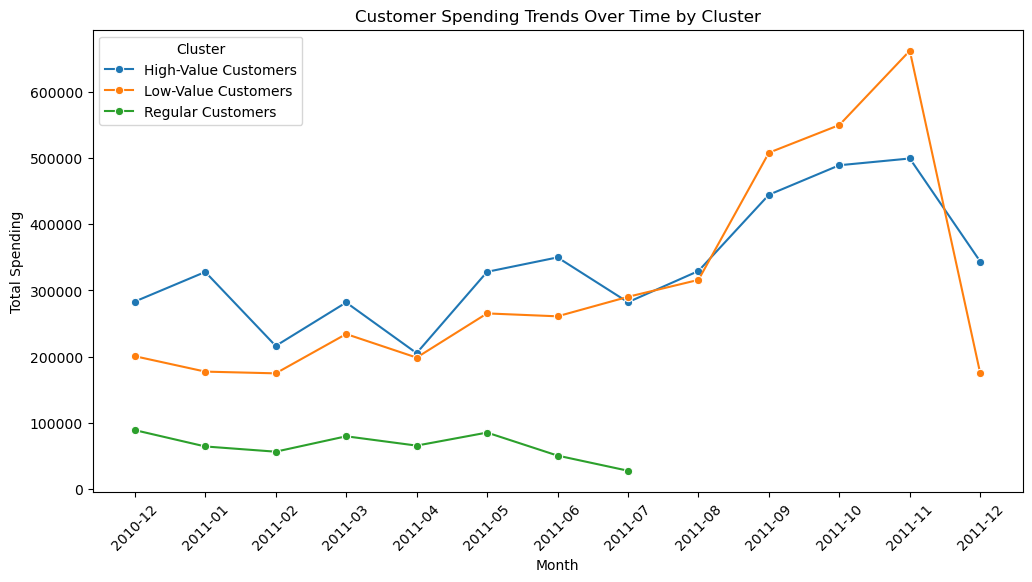

In [92]:
# Ensure datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Check for correct column name
monetary_column = 'TotalPrice'  # Change this if 'Monetary' is incorrect

# Aggregate spending per month per cluster
monthly_trends = df.groupby(['Month', 'Cluster'])[monetary_column].sum().reset_index()

# Convert 'Month' back to datetime for plotting
monthly_trends['Month'] = monthly_trends['Month'].astype(str)

# Plot monthly spending trends
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y=monetary_column, hue='Cluster', data=monthly_trends, marker="o")
plt.xticks(rotation=45)
plt.title("Customer Spending Trends Over Time by Cluster")
plt.xlabel("Month")
plt.ylabel("Total Spending")
plt.show()


<Axes: xlabel='Month'>

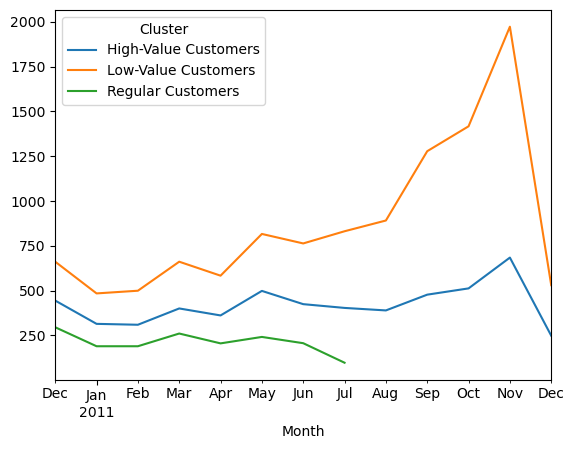

In [98]:
df.groupby(['Month', 'Cluster'])['InvoiceNo'].nunique().unstack().plot()


In [96]:
df[df['Cluster'] == 'Low-Value Customers'].groupby('StockCode')['TotalPrice'].sum().sort_values(ascending=False).head(10)


StockCode
22423     54199.00
POST      45871.21
85123A    36775.00
85099B    35136.83
47566     33386.70
84879     27919.75
23084     24579.03
22086     23527.85
79321     20743.20
23203     17438.56
Name: TotalPrice, dtype: float64

In [102]:
df[df['StockCode'].isin(['22423', 'POST', '85123A', '85099B', '47566', '84879', '23084', '22086', '79321', '23203'])][['StockCode', 'Description']].drop_duplicates()


,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
9,84879,ASSORTED COLOUR BIRD ORNAMENT
45,POST,POSTAGE
46,22086,PAPER CHAIN KIT 50'S CHRISTMAS
175,85099B,JUMBO BAG RED RETROSPOT
176,79321,CHILLI LIGHTS
870,22423,REGENCY CAKESTAND 3 TIER
4401,47566,PARTY BUNTING
122332,23203,JUMBO BAG DOILEY PATTERNS
125691,23084,RABBIT NIGHT LIGHT


In [104]:
df[df['Cluster'] == 'High-Value Customers'].groupby('StockCode')['TotalPrice'].sum().sort_values(ascending=False).head(10)


StockCode
23843     168469.60
23166      79344.02
22423      78904.05
85123A     57307.90
85099B     48076.89
22502      42649.05
M          35271.45
47566      29893.78
23084      26681.89
POST       26272.75
Name: TotalPrice, dtype: float64

In [106]:
df[df['Cluster'] == 'Low-Value Customers'].groupby('StockCode')['TotalPrice'].sum().sort_values(ascending=False).head(10)


StockCode
22423     54199.00
POST      45871.21
85123A    36775.00
85099B    35136.83
47566     33386.70
84879     27919.75
23084     24579.03
22086     23527.85
79321     20743.20
23203     17438.56
Name: TotalPrice, dtype: float64

In [108]:
df[df['Cluster'] == 'Regular Customers'].groupby('StockCode')['TotalPrice'].sum().sort_values(ascending=False).head(10)


StockCode
22423     9489.90
85123A    6520.60
84078A    5776.80
POST      5660.00
47566     5563.85
22328     4520.05
22197     3759.95
22960     3260.50
21621     3035.50
84879     3004.82
Name: TotalPrice, dtype: float64

In [110]:
df[df['StockCode'].isin(['22423', '85123A', '84078A', 'POST', '47566', '22328', '22197', '22960', '21621', '84879'])][['StockCode', 'Description']].drop_duplicates()


,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
9,84879,ASSORTED COLOUR BIRD ORNAMENT
21,22960,JAM MAKING SET WITH JARS
45,POST,POSTAGE
219,22197,SMALL POPCORN HOLDER
538,22328,ROUND SNACK BOXES SET OF 4 FRUITS
870,22423,REGENCY CAKESTAND 3 TIER
873,21621,VINTAGE UNION JACK BUNTING
4401,47566,PARTY BUNTING
21824,84078A,SET/4 WHITE RETRO STORAGE CUBES


In [112]:
df[df['StockCode'].isin(['23843', '23166', '22423', '85123A', '85099B', '22502', 'M', '47566', '23084', 'POST'])][['StockCode', 'Description']].drop_duplicates()


,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
45,POST,POSTAGE
175,85099B,JUMBO BAG RED RETROSPOT
240,22502,PICNIC BASKET WICKER SMALL
870,22423,REGENCY CAKESTAND 3 TIER
1672,M,Manual
4401,47566,PARTY BUNTING
37120,23166,MEDIUM CERAMIC TOP STORAGE JAR
125691,23084,RABBIT NIGHT LIGHT
155405,22502,PICNIC BASKET WICKER 60 PIECES


In [114]:
df[df['StockCode'].isin(['22423', 'POST', '85123A', '85099B', '47566', '84879', '23084', '22086', '79321', '23203'])][['StockCode', 'Description']].drop_duplicates()


,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
9,84879,ASSORTED COLOUR BIRD ORNAMENT
45,POST,POSTAGE
46,22086,PAPER CHAIN KIT 50'S CHRISTMAS
175,85099B,JUMBO BAG RED RETROSPOT
176,79321,CHILLI LIGHTS
870,22423,REGENCY CAKESTAND 3 TIER
4401,47566,PARTY BUNTING
122332,23203,JUMBO BAG DOILEY PATTERNS
125691,23084,RABBIT NIGHT LIGHT


In [118]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')  # Extract Year-Month


In [120]:
monthly_trends = df.groupby('Month')['TotalPrice'].sum().reset_index()
monthly_trends['Month'] = monthly_trends['Month'].astype(str)  # Convert for plotting


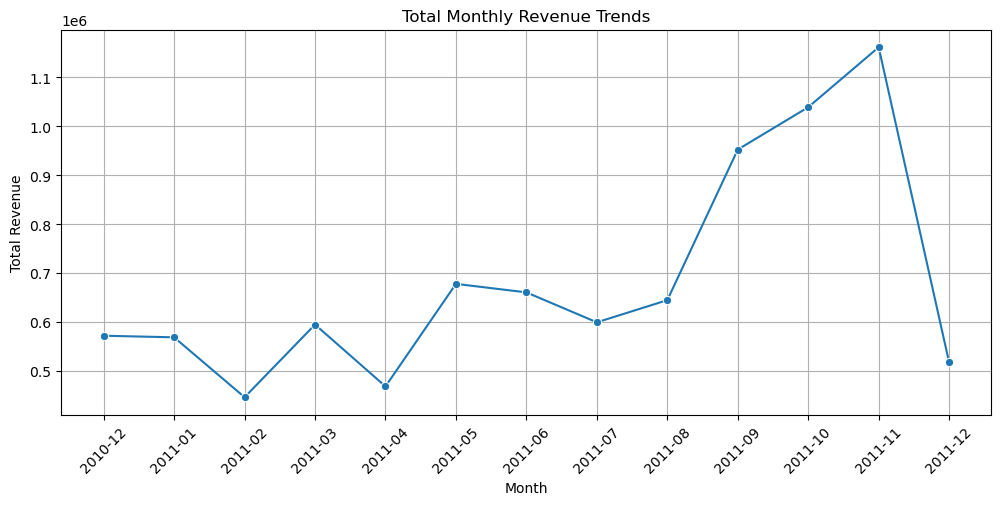

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_trends, x='Month', y='TotalPrice', marker='o')
plt.xticks(rotation=45)
plt.title('Total Monthly Revenue Trends')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()


In [124]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])  # Ensure datetime format
df['Month'] = df['InvoiceDate'].dt.to_period('M')  # Extract Year-Month

# Find first purchase month for each customer
first_purchase = df.groupby('CustomerID')['Month'].min().reset_index()
first_purchase.columns = ['CustomerID', 'FirstPurchaseMonth']


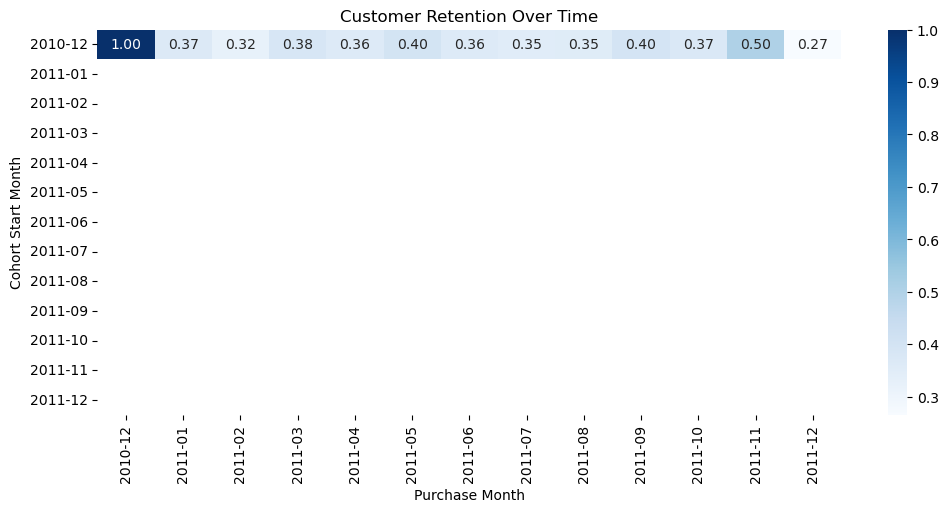

In [126]:
# Merge back to the main data
df = df.merge(first_purchase, on='CustomerID', how='left')

# Create a retention table
retention = df.groupby(['FirstPurchaseMonth', 'Month'])['CustomerID'].nunique().unstack()
retention = retention.divide(retention.iloc[:, 0], axis=0)  # Normalize

# Plot retention rates
plt.figure(figsize=(12, 5))
sns.heatmap(retention, cmap='Blues', annot=True, fmt='.2f')
plt.title('Customer Retention Over Time')
plt.xlabel('Purchase Month')
plt.ylabel('Cohort Start Month')
plt.show()


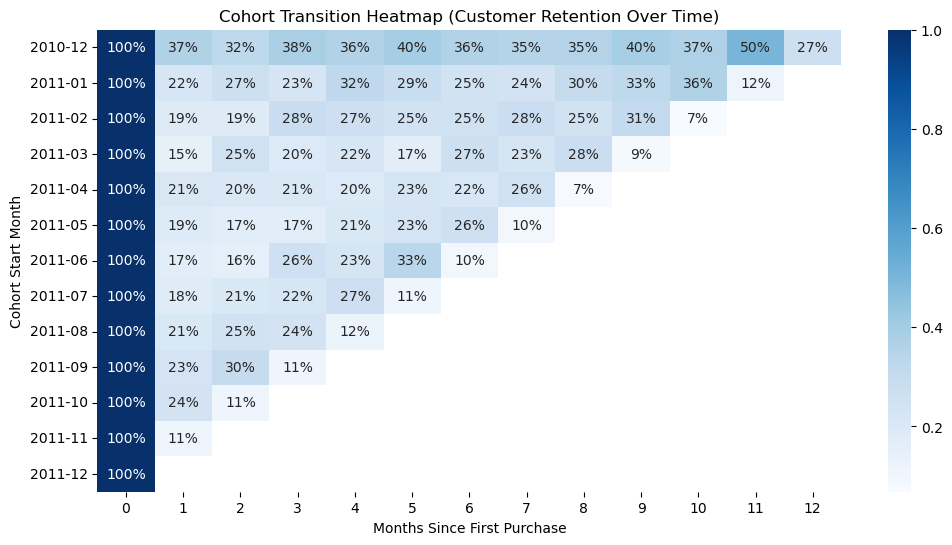

In [129]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset (modify file path accordingly)
df = pd.read_csv(r"C:\rakshitha\FDS\customer-dna\1\cleaned_data.csv", parse_dates=["InvoiceDate"])

# Step 1: Assign Each Customer a Cohort (First Purchase Month)
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")  # Extract Year-Month
df["CustomerID"] = df["CustomerID"].astype(str)  # Ensure CustomerID is a string

# Get first purchase month per customer
first_purchase = df.groupby("CustomerID")["InvoiceMonth"].min()
df = df.merge(first_purchase.rename("CohortMonth"), on="CustomerID")

# Step 2: Calculate Cohort Transition Matrix
df["CohortIndex"] = (df["InvoiceMonth"] - df["CohortMonth"]).apply(lambda x: x.n)

# Pivot table: count unique customers per cohort & month
cohort_counts = df.pivot_table(index="CohortMonth", 
                               columns="CohortIndex", 
                               values="CustomerID", 
                               aggfunc=pd.Series.nunique)

# Step 3: Normalize Data for Retention Rates
cohort_sizes = cohort_counts.iloc[:, 0]  # First column is total customers in cohort
cohort_retention = cohort_counts.divide(cohort_sizes, axis=0)

# Step 4: Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cohort_retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort Transition Heatmap (Customer Retention Over Time)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Start Month")
plt.show()


In [133]:
import pandas as pd

# Load data (replace with your actual dataset)
df = pd.read_csv(r"C:\rakshitha\FDS\customer-dna\1\cleaned_data.csv")

# Convert InvoiceDate to datetime and create month column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Calculate the first purchase month per customer
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

# Calculate retention duration (months since first purchase)
df['RetentionMonths'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)

# Aggregate retention and spending per customer
customer_retention = df.groupby('CustomerID').agg({
    'RetentionMonths': 'max',  # Last purchase month - first purchase month
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'InvoiceNo': 'nunique'  # Unique purchases made
}).reset_index()

# Calculate total spending per customer
customer_retention['TotalSpending'] = customer_retention['Quantity'] * customer_retention['UnitPrice']

# Sort customers by longest retention
high_retention_customers = customer_retention.sort_values(by='RetentionMonths', ascending=False)

# Display top high-retention customers
print(high_retention_customers.head(10))


      CustomerID  RetentionMonths  Quantity  UnitPrice  InvoiceNo  \
3478     17091.0               12      1746   3.139846          9   
667      13230.0               12      1665   2.399051         14   
4085     17937.0               12      1754   3.473256          7   
2611     15898.0               12       570   3.322674          5   
1143     13890.0               12       831   3.401545         10   
481      12971.0               12      9289   2.310328         86   
3018     16458.0               12      2154   1.763366         18   
1630     14560.0               12      1260   4.907027         22   
3788     17530.0               12      1526   2.326269         10   
1317     14135.0               12      3850   2.472463         15   

      TotalSpending  
3478    5482.171385  
667     3994.419476  
4085    6092.090698  
2611    1893.924419  
1143    2826.684273  
481    21460.635574  
3018    3798.291089  
1630    6182.854054  
3788    3549.886548  
1317    9518.981343 

         CustomerID  RetentionMonths      Quantity    UnitPrice    InvoiceNo  \
count   2069.000000      2069.000000   2069.000000  2069.000000  2069.000000   
mean   15333.061866         0.314161    342.008217     5.500381     1.449493   
std     1725.680975         0.650768   1692.895733    48.497738     1.142203   
min    12346.000000         0.000000      1.000000     0.170000     1.000000   
25%    13826.000000         0.000000     91.000000     2.072969     1.000000   
50%    15360.000000         0.000000    182.000000     2.917444     1.000000   
75%    16789.000000         0.000000    343.000000     3.996875     2.000000   
max    18281.000000         2.000000  74215.000000  2033.100000    34.000000   

       TotalSpending  
count    2069.000000  
mean      962.855500  
std      3285.852894  
min         3.750000  
25%       266.760000  
50%       524.286000  
75%       991.000000  
max     97416.922567  


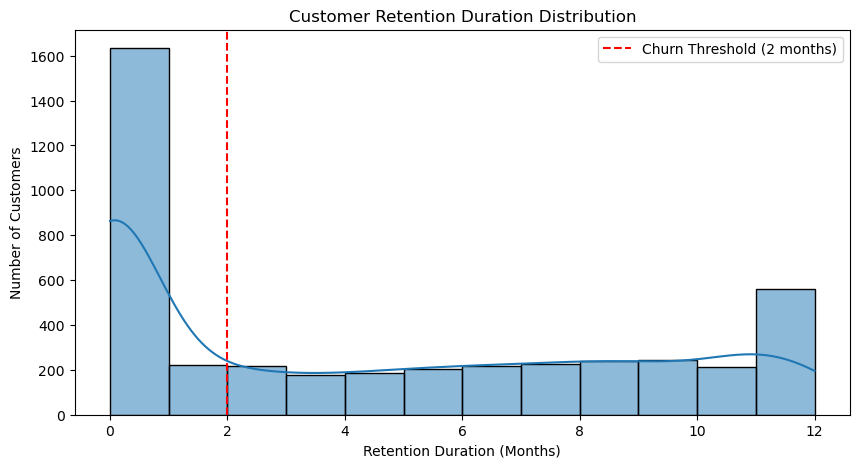

In [135]:
# Find customers with short retention (e.g., <= 2 months)
churned_customers = customer_retention[customer_retention['RetentionMonths'] <= 2]

# Analyze spending habits of churned customers
print(churned_customers.describe())

# Compare high-retention vs. churned customers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(customer_retention['RetentionMonths'], bins=12, kde=True)
plt.axvline(2, color='red', linestyle='dashed', label='Churn Threshold (2 months)')
plt.legend()
plt.title("Customer Retention Duration Distribution")
plt.xlabel("Retention Duration (Months)")
plt.ylabel("Number of Customers")
plt.show()


In [143]:
print(df.columns)


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'InvoiceMonth',
       'CohortMonth', 'RetentionMonths', 'TotalSpending_x', 'TotalSpending_y'],
      dtype='object')


In [151]:
print(churned_products.columns)


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'InvoiceMonth',
       'CohortMonth', 'RetentionMonths', 'TotalSpending_x', 'TotalSpending_y'],
      dtype='object')


In [153]:
(churned_products['TotalSpending_x'] == churned_products['TotalSpending_y']).all()


False

In [155]:
churned_products = churned_products.rename(columns={'TotalSpending_x': 'TotalSpending'})


In [157]:
churned_products = churned_products.rename(columns={'TotalSpending_y': 'TotalSpending'})


In [162]:
print(churned_products.columns)


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'InvoiceMonth',
       'CohortMonth', 'RetentionMonths', 'TotalSpending_x', 'TotalSpending_y'],
      dtype='object')


In [172]:
churned_products = churned_products.copy()
churned_products['TotalSpending'] = churned_products[['TotalSpending_x', 'TotalSpending_y']].sum(axis=1, skipna=True)


In [176]:
print(churned_products.columns)


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'InvoiceMonth',
       'CohortMonth', 'RetentionMonths', 'TotalSpending_x', 'TotalSpending_y'],
      dtype='object')


In [178]:
churned_products = churned_products.copy()  # Prevent SettingWithCopyWarning
churned_products['TotalSpending'] = churned_products[['TotalSpending_x', 'TotalSpending_y']].sum(axis=1, skipna=True)
print(churned_products.columns)  # Check if TotalSpending exists


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'InvoiceMonth',
       'CohortMonth', 'RetentionMonths', 'TotalSpending_x', 'TotalSpending_y',
       'TotalSpending'],
      dtype='object')


In [180]:
print(churned_products.columns.tolist())  # Ensure correct names


['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'InvoiceMonth', 'CohortMonth', 'RetentionMonths', 'TotalSpending_x', 'TotalSpending_y', 'TotalSpending']


In [182]:
print(churned_products[['TotalSpending']].head())  # Ensure it exists


   TotalSpending
0        5406.51
1        5411.55
2        5413.21
3        5411.55
4        5411.55


In [186]:
# Ensure DataFrame is a proper copy
churned_products = df[df['CustomerID'].isin(churned_customers['CustomerID'])].copy()

# Clean column names
churned_products.columns = churned_products.columns.str.strip()

# Recreate TotalSpending safely
churned_products['TotalSpending'] = churned_products[['TotalSpending_x', 'TotalSpending_y']].fillna(0).sum(axis=1)

# Confirm TotalSpending exists before groupby
print(churned_products.columns)
print(churned_products[['TotalSpending']].head())

# Now perform groupby safely
churned_category_analysis = churned_products.groupby('Description').agg({
    'Quantity': 'sum',
    'TotalSpending': 'sum',
    'CustomerID': 'nunique'
}).reset_index()


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'InvoiceMonth',
       'CohortMonth', 'RetentionMonths', 'TotalSpending_x', 'TotalSpending_y',
       'TotalSpending'],
      dtype='object')
   TotalSpending
0        5406.51
1        5411.55
2        5413.21
3        5411.55
4        5411.55


In [188]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\rakshitha\FDS\customer-dna\1\cleaned_data.csv")

# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create InvoiceMonth and CohortMonth
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

# Calculate retention duration
df['RetentionMonths'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)

# Add TotalSpending column
df['TotalSpending'] = df['Quantity'] * df['UnitPrice']

# Aggregate customer retention data
customer_retention = df.groupby('CustomerID').agg({
    'RetentionMonths': 'max',
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'InvoiceNo': 'nunique',
    'TotalSpending': 'sum',   # ✅ Ensure TotalSpending is calculated
}).reset_index()

# Identify churned customers (retention ≤ 2 months)
churned_customers = customer_retention[customer_retention['RetentionMonths'] <= 2]

# Merge TotalSpending back into original dataset, avoiding column conflicts
df = df.merge(
    customer_retention[['CustomerID', 'TotalSpending']], 
    on='CustomerID', 
    how='left', 
    suffixes=('', '_Customer')
)

# Filter churned customer data (Create a copy to avoid warnings)
churned_products = df[df['CustomerID'].isin(churned_customers['CustomerID'])].copy()

# Debugging: Check if TotalSpending exists before grouping
print("Columns before groupby:", churned_products.columns.tolist())

# Ensure TotalSpending is numeric
churned_products['TotalSpending'] = churned_products['TotalSpending'].astype(float)

# Debug: Test TotalSpending alone
test_groupby = churned_products.groupby('Description')[['TotalSpending']].sum()
print(test_groupby.head())  # If this works, proceed with full groupby

# Group by product category and calculate metrics
churned_category_analysis = churned_products.groupby('Description').agg({
    'Quantity': 'sum',
    'TotalSpending': 'sum',
    'CustomerID': 'nunique'
}).reset_index()

# Sort by number of churned customers
churned_category_analysis = churned_category_analysis.sort_values(by='CustomerID', ascending=False)

# Display top churned product categories
print(churned_category_analysis.head(10))


Columns before groupby: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'InvoiceMonth', 'CohortMonth', 'RetentionMonths', 'TotalSpending', 'TotalSpending_Customer']
                               TotalSpending
Description                                 
4 PURPLE FLOCK DINNER CANDLES          65.58
50'S CHRISTMAS GIFT BAG LARGE         450.00
DOLLY GIRL BEAKER                     165.00
I LOVE LONDON MINI BACKPACK           120.35
NINE DRAWER OFFICE TIDY                74.75
                             Description  Quantity  TotalSpending  CustomerID
2396            REGENCY CAKESTAND 3 TIER      1002       12005.10         242
3235  WHITE HANGING HEART T-LIGHT HOLDER      2693        7553.15         237
240        BAKING SET 9 PIECE RETROSPOT        942        4578.90         215
192        ASSORTED COLOUR BIRD ORNAMENT      3178        5255.62         195
2437        REX CASH+CARRY JUMBO SHOPPER       434       

In [190]:
non_churned_customers = customer_retention[customer_retention['RetentionMonths'] > 2]


In [192]:
non_churned_products = df[df['CustomerID'].isin(non_churned_customers['CustomerID'])]


In [194]:
non_churned_category_analysis = non_churned_products.groupby('Description').agg({
    'Quantity': 'sum',
    'TotalSpending': 'sum',
    'CustomerID': 'nunique'
}).reset_index()


In [196]:
comparison = churned_category_analysis.merge(
    non_churned_category_analysis, 
    on="Description", 
    suffixes=('_Churned', '_NonChurned')
)


In [198]:
comparison['Churn_Ratio'] = comparison['CustomerID_Churned'] / (
    comparison['CustomerID_Churned'] + comparison['CustomerID_NonChurned']
)


In [202]:
comparison = comparison.sort_values(by='Churn_Ratio', ascending=False)


In [204]:
spending_comparison = customer_retention.copy()
spending_comparison['Churned'] = spending_comparison['RetentionMonths'] <= 2
spending_summary = spending_comparison.groupby('Churned')['TotalSpending'].describe()
print(spending_summary)


          count         mean          std    min     25%      50%      75%  \
Churned                                                                      
False    2269.0  3409.538458  12120.32951  36.56  714.42  1419.73  2812.34   
True     2069.0   567.987019   2032.62350   3.75  176.68   324.24   579.00   

               max  
Churned             
False    280206.02  
True      77183.60  


In [206]:
churned_products['Avg_Price'] = churned_products['TotalSpending'] / churned_products['Quantity']
avg_price_churned = churned_products.groupby('Description')['Avg_Price'].mean().reset_index()


In [210]:
non_churned_products.loc[:, 'Avg_Price'] = non_churned_products['TotalSpending'] / non_churned_products['Quantity']

avg_price_non_churned = non_churned_products.groupby('Description')['Avg_Price'].mean().reset_index()


In [212]:
price_comparison = avg_price_churned.merge(avg_price_non_churned, on="Description", suffixes=('_Churned', '_NonChurned'))
price_comparison['Price_Difference'] = price_comparison['Avg_Price_Churned'] - price_comparison['Avg_Price_NonChurned']
price_comparison = price_comparison.sort_values(by='Price_Difference', ascending=False)


In [214]:
churned_products['Month'] = churned_products['InvoiceDate'].dt.to_period('M')
churned_monthly_sales = churned_products.groupby('Month')['TotalSpending'].sum().reset_index()


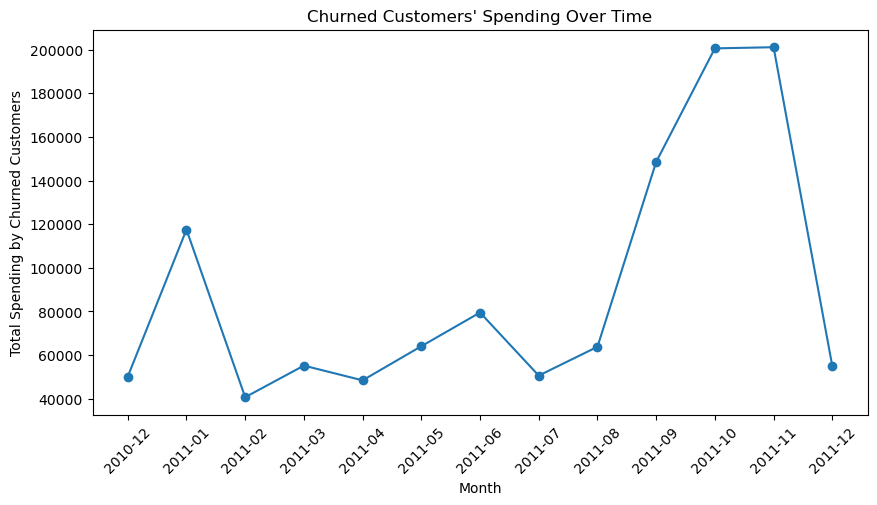

In [216]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(churned_monthly_sales['Month'].astype(str), churned_monthly_sales['TotalSpending'], marker='o')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Spending by Churned Customers")
plt.title("Churned Customers' Spending Over Time")
plt.show()


In [218]:
non_churned_products = df[~df['CustomerID'].isin(churned_customers['CustomerID'])]

# Group by product category and compute metrics
non_churned_category_analysis = non_churned_products.groupby('Description').agg({
    'Quantity': 'sum',
    'TotalSpending': 'sum',
    'CustomerID': 'nunique'
}).reset_index()

# Add average price per product
non_churned_category_analysis['Avg_Price'] = non_churned_category_analysis['TotalSpending'] / non_churned_category_analysis['Quantity']


In [220]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Define features and target
features = customer_retention[['RetentionMonths', 'TotalSpending', 'InvoiceNo']]
target = (customer_retention['RetentionMonths'] <= 2).astype(int)  # Churn = 1, Non-churn = 0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       464
           1       1.00      1.00      1.00       404

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



In [222]:
# Remove RetentionMonths from features
features = customer_retention[['TotalSpending', 'InvoiceNo']]  # Remove 'RetentionMonths'
target = (customer_retention['RetentionMonths'] <= 2).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.84      0.85       464
           1       0.82      0.83      0.83       404

    accuracy                           0.84       868
   macro avg       0.84      0.84      0.84       868
weighted avg       0.84      0.84      0.84       868



In [224]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r"C:\rakshitha\FDS\customer-dna\1\cleaned_data.csv")

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Calculate Total Spending per transaction
df['TotalSpending'] = df['Quantity'] * df['UnitPrice']

# 🟢 1️⃣ Recency: Days since last purchase
latest_date = df['InvoiceDate'].max()
recency_df = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (latest_date - recency_df['InvoiceDate']).dt.days

# 🟢 2️⃣ Frequency: Number of transactions per customer
frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.rename(columns={'InvoiceNo': 'Frequency'}, inplace=True)

# 🟢 3️⃣ Monetary Value: Average order value
monetary_df = df.groupby('CustomerID')['TotalSpending'].sum().reset_index()
monetary_df.rename(columns={'TotalSpending': 'MonetaryValue'}, inplace=True)

# 🟢 4️⃣ Discount Usage: % of products bought at discount
df['Discounted'] = df['UnitPrice'] < df.groupby('StockCode')['UnitPrice'].transform('mean')
discount_df = df.groupby('CustomerID')['Discounted'].mean().reset_index()
discount_df.rename(columns={'Discounted': 'DiscountUsage'}, inplace=True)

# 🟢 5️⃣ Product Category Preference: Most frequently purchased category
category_df = df.groupby(['CustomerID', 'Description'])['Quantity'].sum().reset_index()
category_df = category_df.sort_values(['CustomerID', 'Quantity'], ascending=[True, False])
category_df = category_df.groupby('CustomerID').first().reset_index()
category_df.rename(columns={'Description': 'TopCategory'}, inplace=True)

# 🟢 Merge all features
customer_features = recency_df.merge(frequency_df, on='CustomerID')
customer_features = customer_features.merge(monetary_df, on='CustomerID')
customer_features = customer_features.merge(discount_df, on='CustomerID')
customer_features = customer_features.merge(category_df[['CustomerID', 'TopCategory']], on='CustomerID')

print(customer_features.head())


   CustomerID         InvoiceDate  Recency  Frequency  MonetaryValue  \
0     12346.0 2011-01-18 10:01:00      325          1       77183.60   
1     12347.0 2011-12-07 15:52:00        1          7        4310.00   
2     12348.0 2011-09-25 13:13:00       74          4        1797.24   
3     12349.0 2011-11-21 09:51:00       18          1        1757.55   
4     12350.0 2011-02-02 16:01:00      309          1         334.40   

   DiscountUsage                     TopCategory  
0       1.000000  MEDIUM CERAMIC TOP STORAGE JAR  
1       0.554945      ICE CREAM SUNDAE LIP GLOSS  
2       0.483871             DOUGHNUT LIP GLOSS   
3       0.342466  STRAWBERRY CERAMIC TRINKET POT  
4       0.588235     TEA BAG PLATE RED RETROSPOT  


In [226]:
# Define churn based on recency (e.g., >60 days = churned)
customer_features['Churned'] = (customer_features['Recency'] > 60).astype(int)

# Check churn distribution
print(customer_features['Churned'].value_counts())


Churned
0    2422
1    1916
Name: count, dtype: int64


In [234]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
X = customer_features.drop(columns=['CustomerID', 'TopCategory', 'Churned', 'InvoiceDate'], errors='ignore')
y = customer_features['Churned']  # Define target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=500)

In [242]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Convert InvoiceDate to datetime
customer_features['InvoiceDate'] = pd.to_datetime(customer_features['InvoiceDate'])

# Define churned customers (e.g., no purchase in the last 90 days)
last_date = customer_features['InvoiceDate'].max()
customer_features['Churned'] = (last_date - customer_features['InvoiceDate']).dt.days > 90

# Select features (drop unused columns)
drop_columns = ['CustomerID', 'StockCode', 'Description', 'Country', 'InvoiceNo', 'InvoiceDate']
X = customer_features.drop(columns=drop_columns, errors='ignore')
y = customer_features['Churned'].astype(int)  # Convert True/False to 1/0

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Train XGBoost
xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Print results
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Print classification reports
print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))
print("\nXGBoost Report:\n", classification_report(y_test, y_pred_xgb))


Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0
XGBoost Accuracy: 1.0

Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     32386
           1       1.00      1.00      1.00     47191

    accuracy                           1.00     79577
   macro avg       1.00      1.00      1.00     79577
weighted avg       1.00      1.00      1.00     79577


Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     32386
           1       1.00      1.00      1.00     47191

    accuracy                           1.00     79577
   macro avg       1.00      1.00      1.00     79577
weighted avg       1.00      1.00      1.00     79577


XGBoost Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     32386
           1       1.00      1.00      1.00     47191

    accuracy              

In [244]:
print(customer_features['Churned'].value_counts())


Churned
True     235682
False    162202
Name: count, dtype: int64


In [246]:
from sklearn.model_selection import train_test_split

# Ensure we balance classes in train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [248]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=200)
lr_model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=200)

In [250]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())  # Should be balanced

# Train the model again with resampled data
lr_model.fit(X_train_resampled, y_train_resampled)


Before SMOTE: Churned
1    188545
0    129762
Name: count, dtype: int64
After SMOTE: Churned
1    188545
0    188545
Name: count, dtype: int64


LogisticRegression(class_weight='balanced', max_iter=200)

In [252]:
from sklearn.metrics import classification_report

y_pred = lr_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32440
           1       1.00      1.00      1.00     47137

    accuracy                           1.00     79577
   macro avg       1.00      1.00      1.00     79577
weighted avg       1.00      1.00      1.00     79577



In [254]:
drop_columns = ['CustomerID', 'InvoiceNo', 'InvoiceDate', 'StockCode', 'Description']
X = customer_features.drop(columns=drop_columns, errors='ignore')


In [256]:
y = customer_features['Churned']


In [258]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [260]:
y.value_counts(normalize=True)  # Shows % of each class


Churned
True     0.592338
False    0.407662
Name: proportion, dtype: float64

In [264]:
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)


Index(['Country'], dtype='object')


In [266]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
X['Country'] = encoder.fit_transform(X['Country'])


In [270]:
print(X_train.dtypes)


Quantity        int64
UnitPrice     float64
Country        object
TotalPrice    float64
Churned          bool
dtype: object


In [272]:
import pandas as pd

# Apply One-Hot Encoding to the 'Country' column
X_train = pd.get_dummies(X_train, columns=['Country'], drop_first=True)


In [274]:
X_test = pd.get_dummies(X_test, columns=['Country'], drop_first=True)

# Align train and test datasets to have the same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [277]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [279]:
print(X_train_resampled.dtypes)


Quantity                          int64
UnitPrice                       float64
TotalPrice                      float64
Churned                            bool
Country_Austria                    bool
Country_Bahrain                    bool
Country_Belgium                    bool
Country_Brazil                     bool
Country_Canada                     bool
Country_Channel Islands            bool
Country_Cyprus                     bool
Country_Czech Republic             bool
Country_Denmark                    bool
Country_EIRE                       bool
Country_European Community         bool
Country_Finland                    bool
Country_France                     bool
Country_Germany                    bool
Country_Greece                     bool
Country_Iceland                    bool
Country_Israel                     bool
Country_Italy                      bool
Country_Japan                      bool
Country_Lebanon                    bool
Country_Lithuania                  bool


In [281]:
# Convert boolean columns to integers (0 and 1)
X_train = X_train.astype(int)


In [283]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE on the numeric training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [285]:
print(X_train_resampled.dtypes)


Quantity                        int32
UnitPrice                       int32
TotalPrice                      int32
Churned                         int32
Country_Austria                 int32
Country_Bahrain                 int32
Country_Belgium                 int32
Country_Brazil                  int32
Country_Canada                  int32
Country_Channel Islands         int32
Country_Cyprus                  int32
Country_Czech Republic          int32
Country_Denmark                 int32
Country_EIRE                    int32
Country_European Community      int32
Country_Finland                 int32
Country_France                  int32
Country_Germany                 int32
Country_Greece                  int32
Country_Iceland                 int32
Country_Israel                  int32
Country_Italy                   int32
Country_Japan                   int32
Country_Lebanon                 int32
Country_Lithuania               int32
Country_Malta                   int32
Country_Neth

In [287]:
# Convert numerical features that should be float
X_train["UnitPrice"] = X_train["UnitPrice"].astype(float)
X_train["TotalPrice"] = X_train["TotalPrice"].astype(float)


In [ ]:
from imblearn.over_sampling import SMOTENC

# Identify categorical feature indices (all 'Country_*' columns)
categorical_features = [X_train.columns.get_loc(col) for col in X_train.columns if "Country_" in col]

# Apply SMOTE-NC
smote_nc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)
